### Prediction

In [43]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

Load dataset

In [44]:
import pandas as pd
import numpy as np

DATASET_FILEPATH = '../data/dataset.csv'
df = pd.read_csv(DATASET_FILEPATH)

In [45]:
# test with creating a new feature (gave up because it didn't make much of a difference)
# df['age'] = 2025 - df['year'] + 1

# Define features and target
target = 'price'
features = [
    'make',
    'model',
    'year',
    'body_type',
    'mileage',
    'color', 
    'fuel_type',
    'engine_capacity',
    'engine_power',
    'gearbox', 
    'transmission',
    'pollution_standard'
]

numerical_features = [
    'year',
    'mileage',
    'engine_capacity',
    'engine_power'
]

categorical_features = [
    'make',
    'model',
    'body_type',
    'color',
    'fuel_type',
    'gearbox',
    'transmission',
    'pollution_standard'
]

X = df[features]
y = df[target]

Train test split (stratified by price bins)

In [ ]:
# stratified split by price bins
df['price_bin'] = pd.qcut(df['price'], q=5, labels=False, duplicates='drop')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=df['price_bin'],
    random_state=17
)

print(f"Train set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

Train set: 1514 samples
Test set: 379 samples


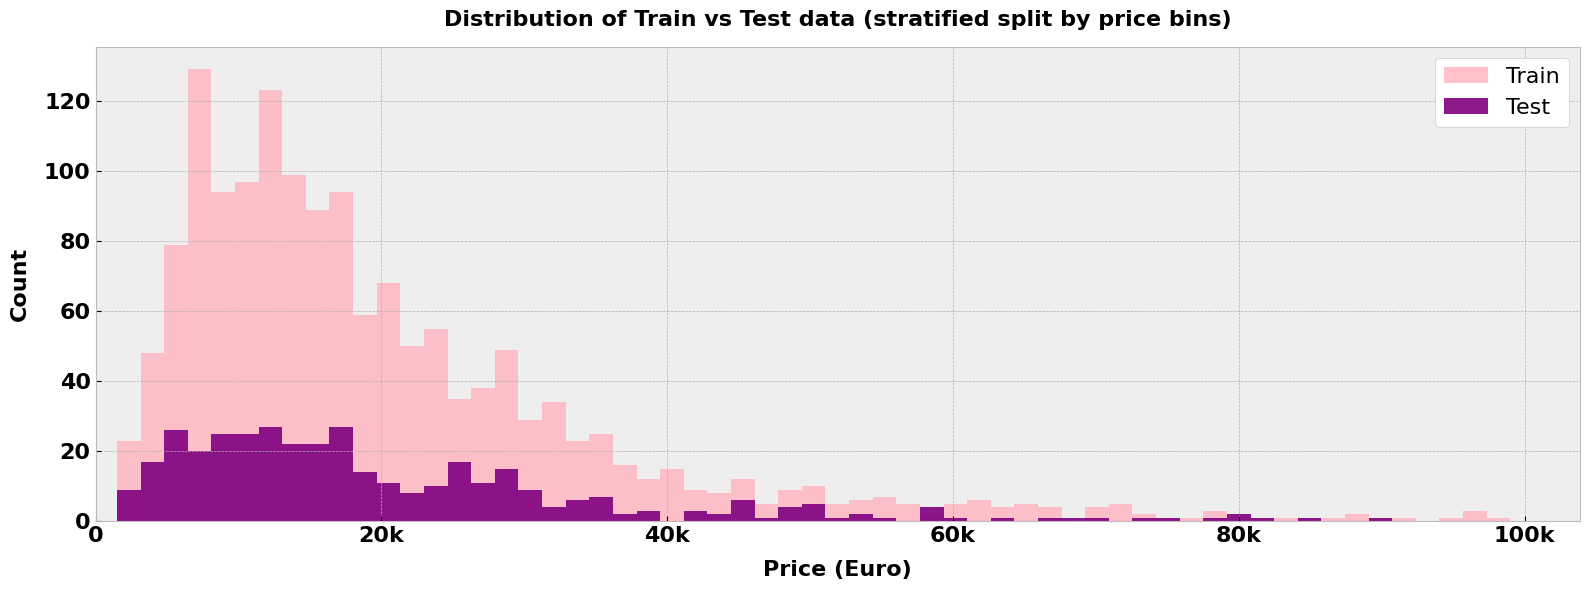

In [47]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plt.style.use('bmh')
plt.figure(figsize=(16, 6))

min_price = min(y_train.min(), y_test.min())
max_price = max(y_train.max(), y_test.max())
bins = np.linspace(min_price, max_price, 60)

plt.hist(y_train, bins=bins, color='lightpink', alpha=0.85, label='Train', edgecolor='none')
plt.hist(y_test, bins=bins, color='purple', alpha=0.9, label='Test', edgecolor='none')

def k_formatter(x, pos):
    if x == 0: return '0'
    return f'{int(x/1000)}k'

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(k_formatter))
ax.tick_params(axis='both', which='major', labelsize=11)

plt.xticks(fontweight='bold', fontsize=16)
plt.yticks(fontweight='bold', fontsize=16)

plt.xlabel('Price (Euro)', fontsize=16, fontweight='bold', labelpad=10)
plt.ylabel('Count', fontsize=16, fontweight='bold', labelpad=10)
plt.title('Distribution of Train vs Test data (stratified split by price bins)', fontsize=16, fontweight='bold', pad=15)

plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=1, fontsize=16)

plt.xlim(left=0)
plt.tight_layout()
plt.show()


### Train

#### 1. Random forest

Create preprocessing pipeline for random forest regressor:
- use ordinal encoding for categorical features
  - converts categories to integers
  - no dimensionality explosion, same number of features
  - ordering is not relevant for tree-based models
- no scaling numerical features

In [48]:
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
    ]
)

In [49]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('model', RandomForestRegressor(random_state=17, n_jobs=-1))
])

Define a hyperparameter grid and perform grid search for hyperparameter tuning.

In [50]:
param_grid = {
    'model__n_estimators': [10, 20, 50, 70, 100, 200],
    'model__max_depth': [5, 10, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 5],
    'model__bootstrap': [True, False]
}

In [51]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,  # 5 fold cross validation
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2
)

print("Starting GridSearchCV...")
grid_search.fit(X_train, y_train)

Starting GridSearchCV...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits


[CV] END model__bootstrap=True, model__max_depth=5, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=10; total time=   0.1s
[CV] END model__bootstrap=True, model__max_depth=5, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=10; total time=   0.1s
[CV] END model__bootstrap=True, model__max_depth=5, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=10; total time=   0.1s
[CV] END model__bootstrap=True, model__max_depth=5, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=20; total time=   0.1s
[CV] END model__bootstrap=True, model__max_depth=5, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=10; total time=   0.1s
[CV] END model__bootstrap=True, model__max_depth=5, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=20; total time=   0.1s
[CV] END model__bootstrap=True, model__max_depth=5, model__min_samples_leaf=1, model__min_samples_sp

,estimator,Pipeline(step...m_state=17))])
,param_grid,"{'model__bootstrap': [True, False], 'model__max_depth': [5, 10, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


Best hyperparameters:

In [52]:
print("Best hyperparameters:")
print(grid_search.best_params_)


Best hyperparameters:
{'model__bootstrap': True, 'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}


Calculate metrics

In [53]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

In [54]:
rf_r2 = r2_score(y_test, y_pred)
rf_mae = mean_absolute_error(y_test, y_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score:        {rf_r2:.4f}")
print(f"MAE (€):         {rf_mae:.2f}")
print(f"RMSE (€):        {rf_rmse:.2f}")

R² Score:        0.8370
MAE (€):         3697.87
RMSE (€):        6474.28


#### 2. XGBoost

Create preprocessing pipeline for xgboost regressor:
- use ordinal encoding for categorical features
  - converts categories to integers
  - no dimensionality explosion, same number of features
  - ordering is not relevant for tree-based models
- no scaling numerical features

In [55]:
preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
    ]
)

In [56]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_xgb),
    ('model', xgb.XGBRegressor(
        random_state=17,
        n_jobs=-1,
        tree_method='hist' 
    ))
])

Define a hyperparameter grid and perform grid search for hyperparameter tuning.

In [57]:
param_grid = {
    'model__n_estimators': [20, 50, 100, 200, 300],
    'model__max_depth': [3, 5, 7],  # typically lower than for rnadom forest
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__subsample': [0.7, 0.8, 0.9],    # fraction of samples used per tree (helps reduce overfitting)
    'model__colsample_bytree': [0.7, 0.8, 0.9],   # fraction of features used per tree (helps reduce overfitting)
    'model__min_child_weight': [1, 3, 5]
}

In [58]:
grid_search_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2
)

print("Starting GridSearchCV for XGBoost...")
grid_search_xgb.fit(X_train, y_train)

Starting GridSearchCV for XGBoost...
Fitting 5 folds for each of 1215 candidates, totalling 6075 fits
[CV] END model__colsample_bytree=0.7, model__learning_rate=0.01, model__max_depth=3, model__min_child_weight=1, model__n_estimators=20, model__subsample=0.7; total time=   0.0s
[CV] END model__colsample_bytree=0.7, model__learning_rate=0.01, model__max_depth=3, model__min_child_weight=1, model__n_estimators=20, model__subsample=0.9; total time=   0.0s[CV] END model__colsample_bytree=0.7, model__learning_rate=0.01, model__max_depth=3, model__min_child_weight=1, model__n_estimators=20, model__subsample=0.9; total time=   0.0s

[CV] END model__colsample_bytree=0.7, model__learning_rate=0.01, model__max_depth=3, model__min_child_weight=1, model__n_estimators=20, model__subsample=0.9; total time=   0.0s
[CV] END model__colsample_bytree=0.7, model__learning_rate=0.01, model__max_depth=3, model__min_child_weight=1, model__n_estimators=20, model__subsample=0.8; total time=   0.0s
[CV] END mode

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.1, ...], 'model__max_depth': [3, 5, ...], 'model__min_child_weight': [1, 3, ...], ...}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


Best hyperparameters:

In [59]:
print("Best hyperparameters:")
print(grid_search_xgb.best_params_)

Best hyperparameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__min_child_weight': 5, 'model__n_estimators': 300, 'model__subsample': 0.9}


Calculate metrics:

In [60]:
best_model_xgb = grid_search_xgb.best_estimator_
y_pred_xgb = best_model_xgb.predict(X_test)

In [61]:
xgb_r2 = r2_score(y_test, y_pred_xgb)
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print(f"R² Score:        {xgb_r2:.4f}")
print(f"MAE (€):         {xgb_mae:.2f}")
print(f"RMSE (€):        {xgb_rmse:.2f}")

R² Score:        0.8951
MAE (€):         3036.56
RMSE (€):        5194.29


##### Compare models

In [62]:
from IPython.display import HTML
HTML("""
<style>
table.dataframe {
    background-color: white !important;
    color: black !important;
}

table.dataframe th, table.dataframe td {
    border: 1px solid #ddd !important;
    padding: 5px !important;
    color: black !important;
}

table.dataframe thead th {
    background-color: #add8e6 !important;
    color: black !important;
    font-weight: bold !important;
    text-align: center !important;
}

table.dataframe tbody td {
    font-weight: bold !important;
}

table.dataframe thead th:first-child {
    display: none;
}
table.dataframe tbody th {
    display: none;
}
</style>
""")

In [63]:
comparison_table = pd.DataFrame({
    'Metric': ['R² Score', 'MAE', 'RMSE'],
    'Random Forest': [
        f"{rf_r2:.4f}",
        f"{rf_mae:.2f}",
        f"{rf_rmse:.2f}"
    ],
    'XGBoost': [
        f"{xgb_r2:.4f}",
        f"{xgb_mae:.2f}",
        f"{xgb_rmse:.2f}"
    ]
})
comparison_table

,Metric,Random Forest,XGBoost
0,R² Score,0.8370,0.8951
1,MAE,3697.87,3036.56
2,RMSE,6474.28,5194.29


### Error analysis

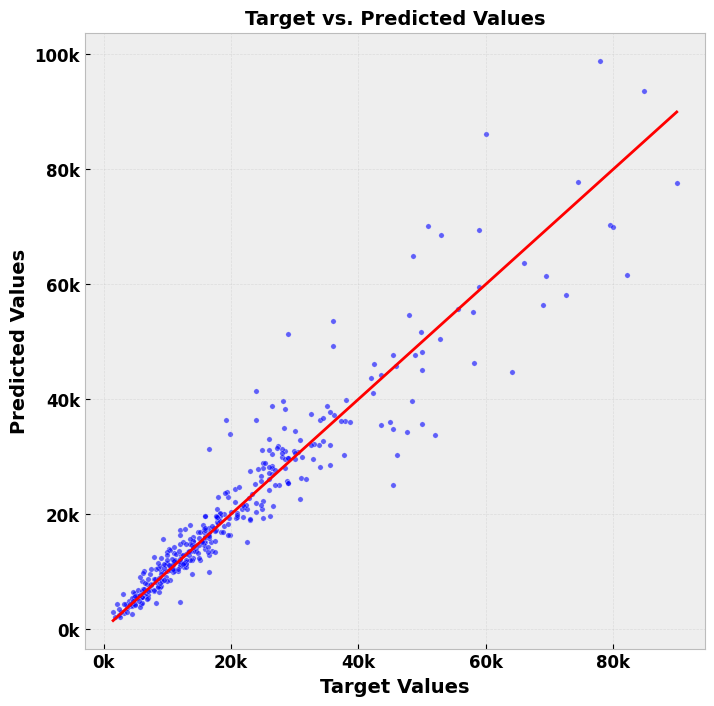

In [64]:
plt.figure(figsize=(8, 8))

# scatter plot of expected vs predicted values
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.6, s=15, color='blue')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, linestyle='-')

plt.title('Target vs. Predicted Values', fontsize=14, fontweight='bold')
plt.xlabel('Target Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=14, fontweight='bold')

plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

from matplotlib.ticker import FuncFormatter
def k_formatter(x, pos):
    return f'{int(x/1000)}k'

plt.gca().xaxis.set_major_formatter(FuncFormatter(k_formatter))
plt.gca().yaxis.set_major_formatter(FuncFormatter(k_formatter))

plt.grid(True, alpha=0.3)
plt.show()
